In [ ]:
import scvi
import torch

import scanpy as sc
import numpy as np
import anndata as ad

from tqdm.notebook import tqdm

In [78]:
adata = sc.read_h5ad("../data/combosciplex.h5ad")

In [79]:
tmp = sc.pp.filter_genes(adata, min_cells=1000, inplace=False)[0]
adata[:, tmp]

View of AnnData object with n_obs × n_vars = 63378 × 12797
    obs: 'sample', 'Size_Factor', 'n.umi', 'RT_well', 'Drug1', 'Drug2', 'Well', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'condition', 'pathway1', 'pathway2', 'split', 'control', 'cell_type'
    var: 'id', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'Drug1_colors', 'Drug2_colors', 'Well_colors', 'condition_colors', 'dendrogram_leiden', 'hvg', 'leiden', 'leiden_colors', 'neighbors', 'pathway1_colors', 'pathway2_colors', 'pathway_colors', 'pca', 'rank_genes_groups', 'split_colors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

In [83]:
adata.X.toarray()

array([[0.       , 0.       , 2.0767338, ..., 0.       , 0.       ,
        0.       ],
       [0.       , 2.0676317, 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       ...,
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ]], dtype=float32)

In [10]:
sc.pp.filter_genes(adata, min_cells=1000)

adata.X = np.round(np.expm1(adata.X.toarray()))

In [11]:
scvi.model.SCVI.setup_anndata(adata)

In [12]:
model = scvi.model.SCVI(adata, n_hidden=1024, n_latent=10)
model.train(max_epochs=100)

/home/icb/egor.antipov/miniconda3/envs/scaling-transformers/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/icb/egor.antipov/miniconda3/envs/scaling-trans ...
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/icb/egor.antipov/miniconda3/envs/scaling-transformers/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/icb/egor.antipov/miniconda3/envs/scaling-trans ...
You are using a CUDA device ('NVIDIA H100 80GB HBM3') that has Tensor Cores. To properly utilize them, you should set `torch.set_f

Training:   0%|          | 0/100 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=100` reached.


In [13]:
model.save(dir_path="./scvi_models/1024_10")

In [14]:
latent = model.get_latent_representation()
latent.shape

(63378, 10)

In [15]:
adata.obsm["latent_10"] = latent

In [16]:
scvi.model.SCVI.setup_anndata(adata)

model = scvi.model.SCVI(adata, n_hidden=1024, n_latent=30)
model.train(max_epochs=100)

/home/icb/egor.antipov/miniconda3/envs/scaling-transformers/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/icb/egor.antipov/miniconda3/envs/scaling-trans ...
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/icb/egor.antipov/miniconda3/envs/scaling-transformers/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/icb/egor.antipov/miniconda3/envs/scaling-trans ...
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/icb/egor.antipov/miniconda3/envs/scaling-transformers/lib/python3.10/site-packages

Training:   0%|          | 0/100 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=100` reached.


In [17]:
model.save(dir_path="./scvi_models/1024_30")

In [18]:
latent = model.get_latent_representation()
latent.shape

(63378, 30)

In [19]:
adata.obsm["latent_30"] = latent

In [20]:
scvi.model.SCVI.setup_anndata(adata)

model = scvi.model.SCVI(adata, n_hidden=1024, n_latent=50)
model.train(max_epochs=100)

/home/icb/egor.antipov/miniconda3/envs/scaling-transformers/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/icb/egor.antipov/miniconda3/envs/scaling-trans ...
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/icb/egor.antipov/miniconda3/envs/scaling-transformers/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/icb/egor.antipov/miniconda3/envs/scaling-trans ...
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/icb/egor.antipov/miniconda3/envs/scaling-transformers/lib/python3.10/site-packages

Training:   0%|          | 0/100 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=100` reached.


In [21]:
model.save(dir_path="./scvi_models/1024_50")

In [22]:
latent = model.get_latent_representation()
latent.shape

(63378, 50)

In [23]:
adata.obsm["latent_50"] = latent

In [78]:
adata.write_h5ad("./data/combosciplex_with_latent.h5ad")

**Test models**

In [111]:
adata = sc.read_h5ad("../data/combosciplex.h5ad")
sc.pp.filter_genes(adata, min_cells=1000)
adata.X = np.round(np.expm1(adata.X.toarray()))

In [124]:
model = scvi.model.SCVI.load("./scvi_models/1024_10/", adata=adata)

INFO     File ./scvi_models/1024_10/model.pt already downloaded                                                    


/home/icb/egor.antipov/miniconda3/envs/scaling-transformers/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/icb/egor.antipov/miniconda3/envs/scaling-trans ...


In [125]:
recon = model.get_normalized_expression(adata, return_numpy=True)
orig = adata.X

In [126]:
recon_scaled = recon * adata.X.sum(axis=1).reshape(-1, 1)

In [127]:
obs = {"type": ["recon" for _ in range(recon_scaled.shape[0])] + ["orig" for _ in range(orig.shape[0])]}
combined = ad.AnnData(X=np.concatenate([recon_scaled, orig]), obs=obs)
print("Created")
sc.pp.pca(combined, n_comps=50)
print("PCA")
sc.pp.neighbors(combined)
print("Neighbors")
sc.tl.umap(combined)
print("Finished")

Created
PCA
Neighbors
Finished


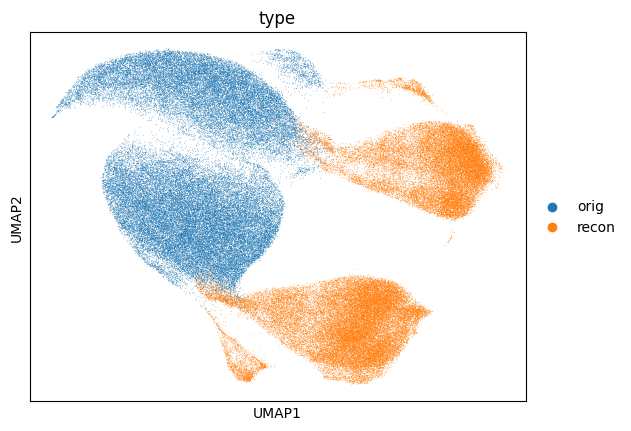

In [118]:
# 50 dims
sc.pl.umap(combined, color="type")

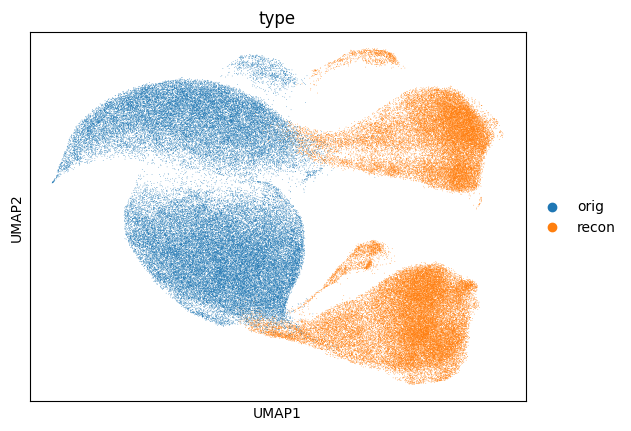

In [123]:
# 30 dims
sc.pl.umap(combined, color="type")

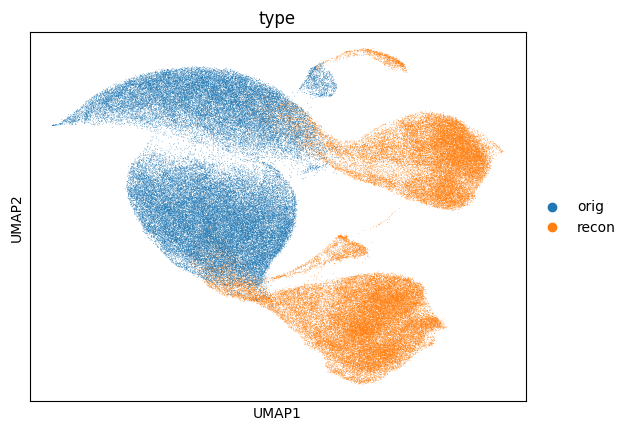

In [128]:
# 10 dims
sc.pl.umap(combined, color="type")

**Normal distribution**

In [129]:
adata = sc.read_h5ad("../data/combosciplex.h5ad")
sc.pp.filter_genes(adata, min_cells=1000)

In [85]:
scvi.model.SCVI.setup_anndata(adata)

model = scvi.model.SCVI(adata, n_hidden=1024, n_latent=10, gene_likelihood="normal")
model.train(max_epochs=100)

/home/icb/egor.antipov/miniconda3/envs/scaling-transformers/lib/python3.10/site-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.X does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)
/home/icb/egor.antipov/miniconda3/envs/scaling-transformers/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)
/home/icb/egor.antipov/miniconda3/envs/scaling-transformers/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/icb/egor.antipov/miniconda3/envs/scaling-trans ...
GPU available: True (cuda), used: True
TPU ava

Training:   0%|          | 0/100 [00:00<?, ?it/s]


Detected KeyboardInterrupt, attempting graceful shutdown ...
Exception ignored in: <function WeakValueDictionary.__init__.<locals>.remove at 0x7f10570d7ac0>
Traceback (most recent call last):
  File "/home/icb/egor.antipov/miniconda3/envs/scaling-transformers/lib/python3.10/weakref.py", line 106, in remove
    def remove(wr, selfref=ref(self), _atomic_removal=_remove_dead_weakref):
KeyboardInterrupt: 


In [62]:
model.save(dir_path="./scvi_models/gaussian_1024_10")

latent = model.get_latent_representation()
print(latent.shape)

adata.obsm["latent_10"] = latent

(63378, 10)


In [63]:
scvi.model.SCVI.setup_anndata(adata)

model = scvi.model.SCVI(adata, n_hidden=1024, n_latent=30, gene_likelihood="normal")
model.train(max_epochs=100)

/home/icb/egor.antipov/miniconda3/envs/scaling-transformers/lib/python3.10/site-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.X does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)
/home/icb/egor.antipov/miniconda3/envs/scaling-transformers/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)
/home/icb/egor.antipov/miniconda3/envs/scaling-transformers/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/icb/egor.antipov/miniconda3/envs/scaling-trans ...
GPU available: True (cuda), used: True
TPU ava

Training:   0%|          | 0/100 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=100` reached.


In [64]:
model.save(dir_path="./scvi_models/gaussian_1024_30")

latent = model.get_latent_representation()
print(latent.shape)

adata.obsm["latent_30"] = latent

(63378, 30)


In [ ]:
scvi.model.SCVI.setup_anndata(adata)

model = scvi.model.SCVI(adata, n_hidden=1024, n_latent=50, gene_likelihood="normal")
model.train(max_epochs=100)

/home/icb/egor.antipov/miniconda3/envs/scaling-transformers/lib/python3.10/site-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.X does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)
/home/icb/egor.antipov/miniconda3/envs/scaling-transformers/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)
/home/icb/egor.antipov/miniconda3/envs/scaling-transformers/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/icb/egor.antipov/miniconda3/envs/scaling-trans ...
GPU available: True (cuda), used: True
TPU ava

Training:   0%|          | 0/100 [00:00<?, ?it/s]

In [ ]:
model.save(dir_path="./scvi_models/gaussian_1024_50")

latent = model.get_latent_representation()
print(latent.shape)

adata.obsm["latent_50"] = latent

In [ ]:
adata.write_h5ad("./data/combosciplex_with_gaussian_latent.h5ad")

In [131]:
scvi.model.SCVI.setup_anndata(adata)

model = scvi.model.SCVI(adata, n_hidden=1024, n_latent=40, gene_likelihood="normal")
model.train(max_epochs=100)

/home/icb/egor.antipov/miniconda3/envs/scaling-transformers/lib/python3.10/site-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.X does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)
/home/icb/egor.antipov/miniconda3/envs/scaling-transformers/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)
/home/icb/egor.antipov/miniconda3/envs/scaling-transformers/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/icb/egor.antipov/miniconda3/envs/scaling-trans ...
GPU available: True (cuda), used: True
TPU ava

Training:   0%|          | 0/100 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=100` reached.


In [132]:
model.save(dir_path="./scvi_models/gaussian_1024_40")

**Testing**

In [133]:
adata = sc.read_h5ad("../data/combosciplex.h5ad")
sc.pp.filter_genes(adata, min_cells=1000)

scvi.model.SCVI.setup_anndata(adata)

/home/icb/egor.antipov/miniconda3/envs/scaling-transformers/lib/python3.10/site-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.X does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)
/home/icb/egor.antipov/miniconda3/envs/scaling-transformers/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


In [147]:
model = scvi.model.SCVI.load("./scvi_models/gaussian_1024_40/", adata=adata)

INFO     File ./scvi_models/gaussian_1024_40/model.pt already downloaded                                           


/home/icb/egor.antipov/miniconda3/envs/scaling-transformers/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/icb/egor.antipov/miniconda3/envs/scaling-trans ...
/home/icb/egor.antipov/miniconda3/envs/scaling-transformers/lib/python3.10/site-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.X does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)
/home/icb/egor.antipov/miniconda3/envs/scaling-transformers/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


In [148]:
n = int(len(adata) / 1024) + 1

recon = []
for i in tqdm(range(n)):
    if i != 51:
        tmp = model.get_normalized_expression(adata[int(i*1024):int((i+1)*1024)], return_numpy=True)
        recon.append(tmp * adata[int(i*1024):int((i+1)*1024)].X.toarray().sum(1).reshape(-1, 1))
    torch.cuda.empty_cache()
recon = np.concatenate(recon)

orig = adata.X.toarray()

  0%|          | 0/62 [00:00<?, ?it/s]

INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                         

In [149]:
obs = {"type": ["recon" for _ in range(recon.shape[0])] + ["orig" for _ in range(orig.shape[0])]}
combined = ad.AnnData(X=np.concatenate([recon, orig], axis=0), obs=obs)
print("Created")
sc.pp.pca(combined, n_comps=50)
print("PCA")
sc.pp.neighbors(combined)
print("Neighbors")
sc.tl.umap(combined)
print("Finished")

Created
PCA
Neighbors
Finished


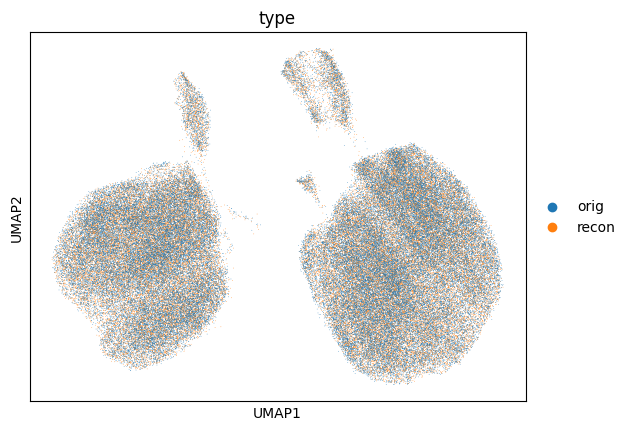

In [96]:
# 50 dims
sc.pl.umap(combined, color="type")

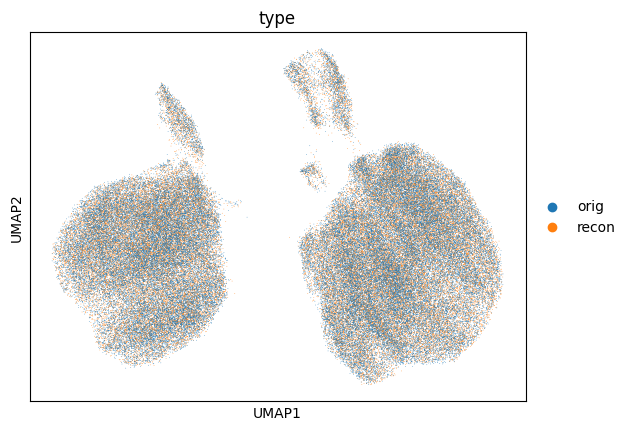

In [150]:
# 40 dims
sc.pl.umap(combined, color="type")

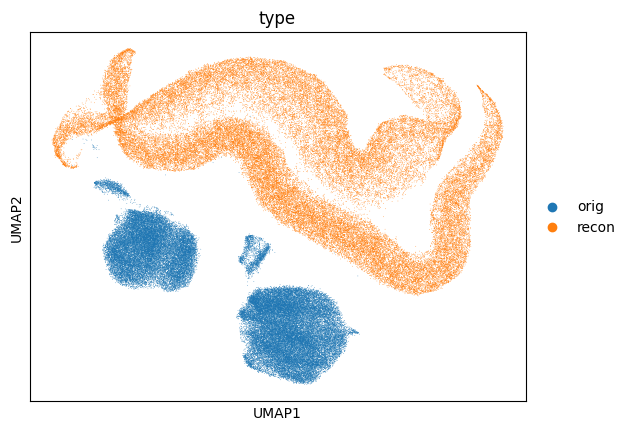

In [146]:
# 30 dims
sc.pl.umap(combined, color="type")

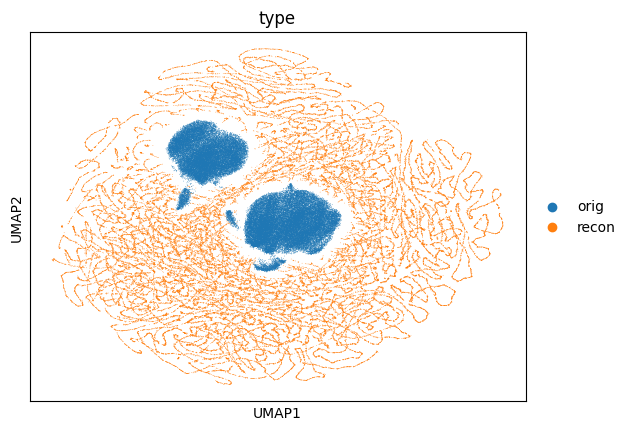

In [103]:
# 10 dims
sc.pl.umap(combined, color="type")